# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Annisa Safitri Ramadhani Harahap
- **Email:** CDCC012D6X0997@student.devacademy.id
- **ID Dicoding:** CDCC012D6X0997

## Menentukan Pertanyaan Bisnis

Berikut adalah dua pertanyaan bisnis dengan menerapkan prinsip SMART:

### Pertanyaan Bisnis Baru
1. Bagaimana tren pertumbuhan total peminjaman sepeda setiap bulan selama periode Januari 2011 hingga Desember 2012, dan berapa rata-rata growth rate bulanannya?
    *   Specific: Fokus pada total peminjaman bulanan dan tahunan
    *   Measurable: Metrik: total peminjaman, rata-rata harian, growth rate (%)
    *   Achievable: Data tersedia lengkap
    *   Relevant: Membantu perencanaan kapasitas dan promosi
    *   Time-bound: Periode 2011-2012


2. Bagaimana pola rata-rata peminjaman sepeda per jam pada hari kerja dibandingkan hari libur selama periode 2011–2012, dan pada jam berapa puncak peminjaman tertinggi terjadi di masing-masing kondisi tersebut?
    * Specific: Pola per jam, perbandingan workingday vs holiday/weekend
    * Measurable: Metrik: rata-rata peminjaman per jam
    * Achievable: Data tersedia di hour.csv
    * Relevant: Untuk pengaturan operasional dan penambahan armada
    * Time-bound: Seluruh periode data

3. Musim apa yang memiliki rata-rata peminjaman sepeda harian tertinggi dan terendah selama periode 2011–2012, dan berapa selisih rata-rata peminjaman antara musim tersebut?
    * Specific:  Fokus pada variabel musim
    * Measurable:  Metrik: rata-rata peminjaman harian per musim
    * Action-Oriented: Data tersedia di day.csv
    * Relevant: Untuk strategi promosi musiman
    * Time-bound: Seluruh periode data


## Import Semua Packages/Library yang Digunakan

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
day_df  = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

print("Sample data day.csv:")
print(day_df.head())

print("\nSample data hour.csv:")
print(hour_df.head())


Sample data day.csv:
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  

Samp

In [ ]:
print(day_df.info())
print(hour_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns

In [ ]:
print(day_df.describe())
print(hour_df.describe())

          instant      season          yr        mnth     holiday     weekday  \
count  731.000000  731.000000  731.000000  731.000000  731.000000  731.000000   
mean   366.000000    2.496580    0.500684    6.519836    0.028728    2.997264   
std    211.165812    1.110807    0.500342    3.451913    0.167155    2.004787   
min      1.000000    1.000000    0.000000    1.000000    0.000000    0.000000   
25%    183.500000    2.000000    0.000000    4.000000    0.000000    1.000000   
50%    366.000000    3.000000    1.000000    7.000000    0.000000    3.000000   
75%    548.500000    3.000000    1.000000   10.000000    0.000000    5.000000   
max    731.000000    4.000000    1.000000   12.000000    1.000000    6.000000   

       workingday  weathersit        temp       atemp         hum   windspeed  \
count  731.000000  731.000000  731.000000  731.000000  731.000000  731.000000   
mean     0.683995    1.395349    0.495385    0.474354    0.627894    0.190486   
std      0.465233    0.5448

In [ ]:
print(day_df.isnull().sum())
print(hour_df.isnull().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [ ]:
print(day_df['season'].unique())

['Spring' 'Summer' 'Fall' 'Winter']


### Assessing Data

In [ ]:
print("===== day_df.info() =====")
print(day_df.info())
print("\n===== hour_df.info() =====")
print(hour_df.info())

print("\n--- Null counts (day_df) ---")
print(day_df.isnull().sum())
print("\n--- Null counts (hour_df) ---")
print(hour_df.isnull().sum())

print("\nDuplicated rows (day_df):", day_df.duplicated().sum())
print("Duplicated rows (hour_df):", hour_df.duplicated().sum())

print("\ndtype of 'dteday' in day_df :", day_df['dteday'].dtype)
print("dtype of 'dteday' in hour_df:", hour_df['dteday'].dtype)

print("\n--- Rows where 'hum' == 0 (day_df) ---")
print(day_df[day_df['hum'] == 0])
print("\n--- Rows where 'hum' == 0 (hour_df) ---")
print(hour_df[hour_df['hum'] == 0])


===== day_df.info() =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

===== hour_df.info() =====
<class 'pandas.core.frame.DataFram

#### Outlier detection (IQR)

In [ ]:
def iqr_outlier_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return lower, upper

for col in ['cnt','casual','registered']:
    print('day_df', col, iqr_outlier_bounds(day_df[col]))
    print('hour_df', col, iqr_outlier_bounds(hour_df[col]))


day_df cnt (np.float64(-1054.0), np.float64(10162.0))
hour_df cnt (np.float64(-321.5), np.float64(642.5))
day_df casual (np.float64(-855.25), np.float64(2266.75))
hour_df casual (np.float64(-62.0), np.float64(114.0))
day_df registered (np.float64(-922.25), np.float64(8195.75))
hour_df registered (np.float64(-245.0), np.float64(499.0))


## Cleaning

In [ ]:
# Convert 'dteday' to datetime
day_df['dteday']  = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Replace 'hum' == 0 with median (excluding zeros)
for df in [day_df, hour_df]:
    median_hum = df.loc[df['hum'] != 0, 'hum'].median()
    df['hum'] = df['hum'].replace(0, median_hum)

### Capping outliers

In [ ]:
def cap_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower, upper)
    return df

day_df  = cap_iqr(day_df,  ['cnt', 'casual', 'registered'])
hour_df = cap_iqr(hour_df, ['cnt', 'casual', 'registered'])

### Mapping categorical columns

In [ ]:
season_map     = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
weathersit_map = {1: "Clear", 2: "Misty", 3: "Light Snow/Rain", 4: "Heavy Rain"}
yr_map         = {0: "2011", 1: "2012"}

for df in [day_df, hour_df]:
    df['season']     = df['season'].map(season_map)
    df['weathersit'] = df['weathersit'].map(weathersit_map)
    df['yr']         = df['yr'].map(yr_map)

print("\nSample after mapping (day_df):")
print(day_df[['season', 'weathersit', 'yr']].sample(8))
print("\nSample after mapping (hour_df):")
print(hour_df[['season', 'weathersit', 'yr']].sample(8))


Sample after mapping (day_df):
     season       weathersit    yr
116  Summer            Misty  2011
248    Fall  Light Snow/Rain  2011
16   Spring            Misty  2011
101  Summer            Misty  2011
427  Spring            Misty  2012
298  Winter            Misty  2011
146  Summer            Clear  2011
694  Winter            Clear  2012

Sample after mapping (hour_df):
       season weathersit    yr
2533   Summer      Clear  2011
15911  Winter      Misty  2012
6163     Fall      Misty  2011
16926  Winter      Misty  2012
10213  Spring      Clear  2012
1902   Summer      Clear  2011
5021     Fall      Clear  2011
7222   Winter      Clear  2011


## Exploratory Data Analysis (EDA)

### Explore ...

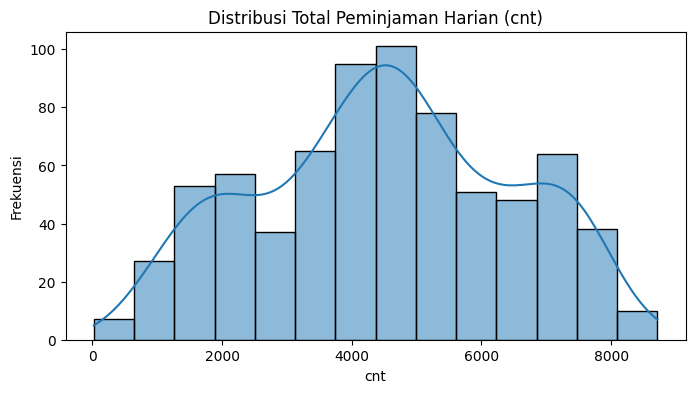

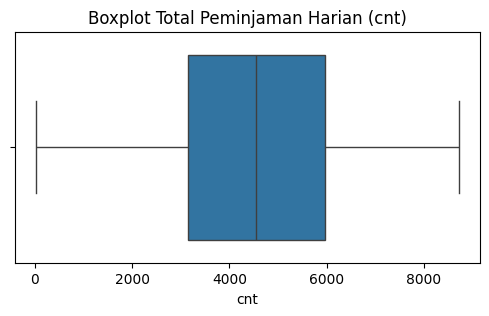

In [ ]:
# Distribusi cnt (total peminjaman harian)
plt.figure(figsize=(8,4))
sns.histplot(day_df['cnt'], kde=True)
plt.title('Distribusi Total Peminjaman Harian (cnt)')
plt.xlabel('cnt')
plt.ylabel('Frekuensi')
plt.show()

# Boxplot cnt
plt.figure(figsize=(6,3))
sns.boxplot(x=day_df['cnt'])
plt.title('Boxplot Total Peminjaman Harian (cnt)')
plt.show()


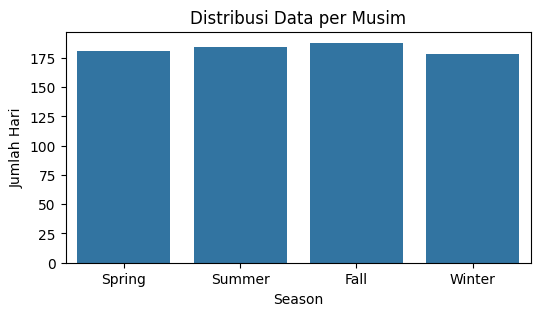

In [ ]:
# Distribusi musim
plt.figure(figsize=(6,3))
sns.countplot(x='season', data=day_df)
plt.title('Distribusi Data per Musim')
plt.xlabel('Season')
plt.ylabel('Jumlah Hari')
plt.show()


In [ ]:
# 3.1. Monthly Trend
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
day_df['year'] = day_df['dteday'].dt.year.astype(str)
day_df['month'] = day_df['dteday'].dt.month

# Agregasi bulanan
monthly = day_df.groupby(['year', 'month']).agg({'cnt': 'sum'}).reset_index()
monthly['month_name'] = pd.to_datetime(monthly['month'], format='%m').dt.strftime('%b')
monthly['growth_rate_%'] = monthly['cnt'].pct_change().round(4) * 100

# Agregasi tahunan
yearly = day_df.groupby('year').agg(
    total_rentals=('cnt', 'sum'),
    avg_daily_rentals=('cnt', 'mean')
).reset_index()
yearly['yoy_growth_%'] = yearly['total_rentals'].pct_change().round(4) * 100

print("MONTHLY AGGREGATION (day.csv — fixed)")
print(monthly)
print("\nYEARLY AGGREGATION (day.csv — fixed)")
print(yearly)



MONTHLY AGGREGATION (day.csv — fixed)
    year  month     cnt month_name  growth_rate_%
0   2011      1   38189        Jan            NaN
1   2011      2   48215        Feb          26.25
2   2011      3   64045        Mar          32.83
3   2011      4   94870        Apr          48.13
4   2011      5  135821        May          43.17
5   2011      6  143512        Jun           5.66
6   2011      7  141341        Jul          -1.51
7   2011      8  136691        Aug          -3.29
8   2011      9  127418        Sep          -6.78
9   2011     10  123511        Oct          -3.07
10  2011     11  102167        Nov         -17.28
11  2011     12   87323        Dec         -14.53
12  2012      1   96744        Jan          10.79
13  2012      2  103137        Feb           6.61
14  2012      3  164875        Mar          59.86
15  2012      4  174224        Apr           5.67
16  2012      5  195865        May          12.42
17  2012      6  202830        Jun           3.56
18  2012    

In [ ]:
# 3.2. Hourly Pattern
hour_df['day_type'] = hour_df['workingday'].map({1:'Workingday', 0:'Holiday/Weekend'})
hourly_pattern = hour_df.groupby(['day_type','hr']).agg(
    avg_rentals_per_hour=('cnt','mean')
).reset_index()
print(hourly_pattern.head(10))

          day_type  hr  avg_rentals_per_hour
0  Holiday/Weekend   0             90.800000
1  Holiday/Weekend   1             69.508696
2  Holiday/Weekend   2             53.171053
3  Holiday/Weekend   3             25.775330
4  Holiday/Weekend   4              8.264317
5  Holiday/Weekend   5              8.689189
6  Holiday/Weekend   6             18.742358
7  Holiday/Weekend   7             43.406926
8  Holiday/Weekend   8            105.653680
9  Holiday/Weekend   9            171.623377


In [ ]:
season_map = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
day_df['season_label'] = day_df['season'].map(season_map)

season_agg = day_df.groupby('season', as_index=False)['cnt'].mean()
season_agg.rename(columns={'cnt': 'avg_daily'}, inplace=True)

print(season_agg)


   season    avg_daily
0    Fall  5644.303191
1  Spring  2604.132597
2  Summer  4992.331522
3  Winter  4728.162921


**Insight:**

1. **Monthly Trend (Total Penyewaan Sepeda per Bulan)**

*Insight Utama:*

a. Pola Musiman yang Konsisten:
- Data menunjukkan pola musiman yang jelas, dengan peningkatan signifikan pada bulan-bulan musim panas (Mei hingga September) dan penurunan pada musim dingin (Desember hingga Februari).
- Puncak Penyewaan: Bulan dengan penyewaan tertinggi adalah September 2012 (218,573 penyewaan), diikuti oleh Agustus 2012 (214,503 penyewaan) dan Juli 2012 (203,607 penyewaan).
- Penyewaan Terendah: Bulan dengan penyewaan terendah adalah Januari 2011 (38,189 penyewaan), yang kemungkinan besar disebabkan oleh cuaca dingin dan kondisi yang kurang mendukung untuk bersepeda.

b. Perbandingan Tahun:
Tahun 2012 menunjukkan peningkatan signifikan dalam jumlah penyewaan dibandingkan tahun 2011.Pertumbuhan YoY: 64.88% dimana Total 2011 yaitu 1,243,103 peminjaman, Total 2012 yaitu 2,049,576 peminjaman Hal ini mengindikasikan pertumbuhan popularitas layanan penyewaan sepeda atau peningkatan jumlah pengguna.

c. Tren Bulanan: Penyewaan sepeda cenderung meningkat secara bertahap dari awal tahun hingga mencapai puncak di musim panas, kemudian menurun menjelang akhir tahun.

2. **Hourly Pattern (Rata-rata Penyewaan Sepeda per Jam)**

*Insight Utama:*

a. Hari Kerja vs Akhir Pekan:
- Pada hari kerja, rata-rata penyewaan sepeda lebih rendah pada malam hari (pukul 0:00–5:00) dan mulai meningkat pada pagi hari (pukul 7:00–9:00) serta sore hari (pukul 17:00–19:00). Hal ini menunjukkan bahwa sepeda banyak digunakan untuk keperluan komuter.
- Pada akhir pekan, rata-rata penyewaan lebih tinggi sepanjang hari, dengan puncak pada siang hingga sore hari (pukul 12:00–16:00), mencerminkan penggunaan untuk rekreasi.

b. Jam dengan Penyewaan Tertinggi:
- Hari Kerja: Puncak penyewaan terjadi pada pagi hari (sekitar pukul 8:00) dan sore hari (sekitar pukul 17:00).
- Akhir Pekan: Penyewaan tertinggi terjadi pada siang hari (sekitar pukul 13:00).

c. Jam dengan Penyewaan Terendah:
Penyewaan sepeda sangat rendah pada malam hari (pukul 0:00–5:00) baik pada hari kerja maupun akhir pekan.

3. **Rentals by Season and Weather (Penyewaan Berdasarkan Musim dan Cuaca)**

*Insight Utama:*

a. Musim dengan Penyewaan Tertinggi:
- Musim Gugur (Fall): Rata-rata penyewaan tertinggi (5,878 penyewaan/hari) terjadi pada musim gugur, terutama saat cuaca cerah (Clear).
- Musim Panas (Summer): Menyusul dengan rata-rata 5,548 penyewaan/hari, menunjukkan bahwa cuaca hangat sangat mendukung aktivitas bersepeda.

b. Pengaruh Cuaca:
-Cuaca Cerah (Clear): Penyewaan tertinggi terjadi saat cuaca cerah di semua musim.
- Cuaca Buruk (Light Snow/Rain): Penyewaan menurun drastis saat cuaca buruk, terutama pada musim semi (Spring) dan musim dingin (Winter).

c. Interaksi Musim dan Cuaca:
Kombinasi musim panas dengan cuaca cerah menghasilkan jumlah penyewaan tertinggi.
Sebaliknya, musim dingin dengan cuaca buruk menghasilkan jumlah penyewaan terendah.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

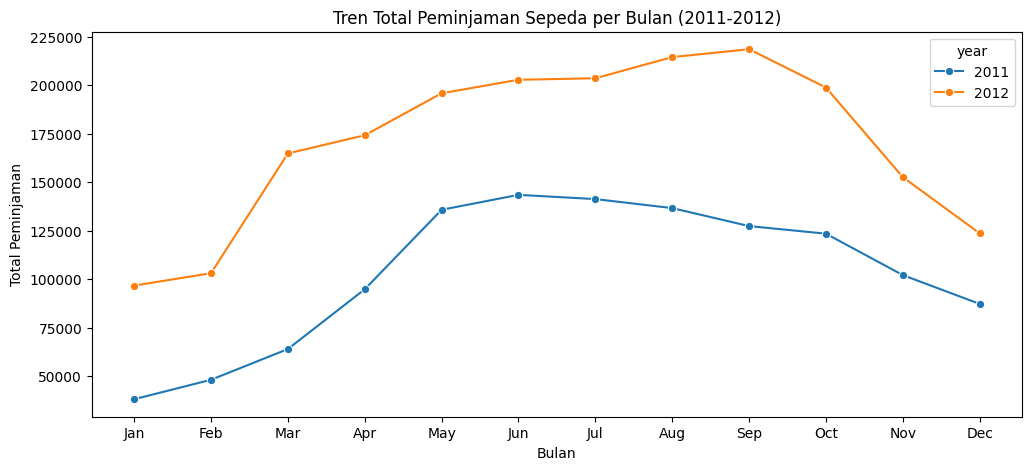

In [ ]:
# 4a. Monthly and Yearly Growth Trend
plt.figure(figsize=(12,5))
sns.lineplot(x='month_name', y='cnt', hue='year', data=monthly, marker='o')
plt.title('Tren Total Peminjaman Sepeda per Bulan (2011-2012)')
plt.xlabel('Bulan')
plt.ylabel('Total Peminjaman')
plt.show()

### Pertanyaan 2:

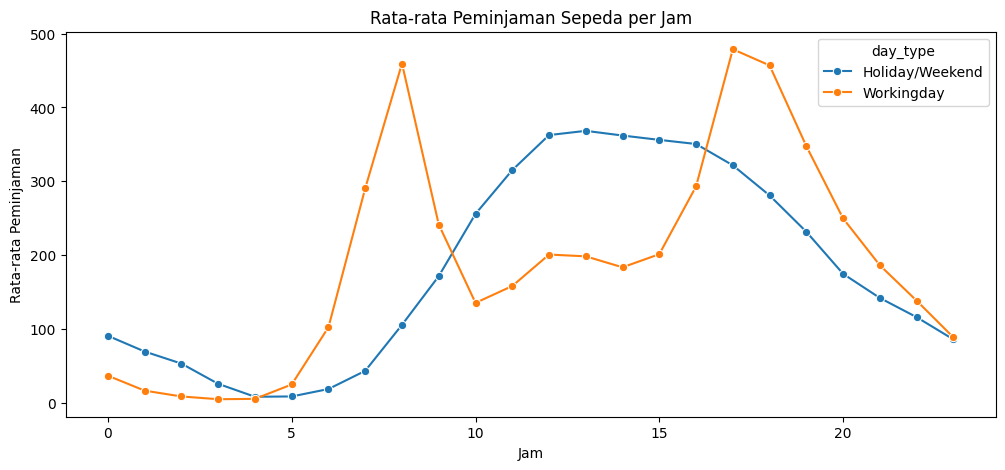

In [ ]:
# 4b. Hourly Rental Pattern: Working Day vs Holiday/Weekend
plt.figure(figsize=(12,5))
sns.lineplot(x='hr', y='avg_rentals_per_hour', hue='day_type', data=hourly_pattern, marker='o')
plt.title('Rata-rata Peminjaman Sepeda per Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Peminjaman')
plt.show()

<Figure size 700x400 with 0 Axes>

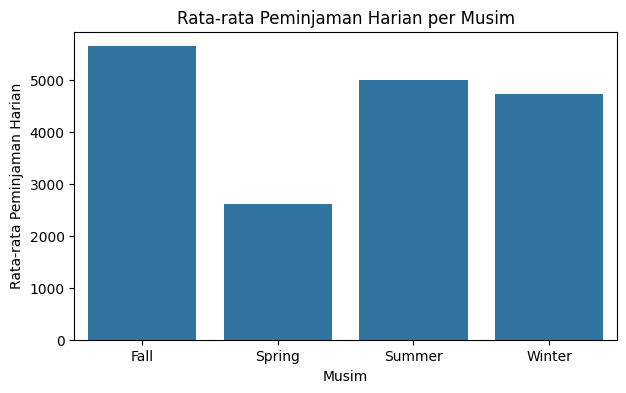

In [ ]:
# 4c. Season & Weather Impact
plt.figure(figsize=(7,4))
sns.barplot(x='season', y='avg_daily', data=season_agg, errorbar=None)
plt.title('Rata-rata Peminjaman Harian per Musim')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Peminjaman Harian')
plt.show()

In [ ]:
day_df.to_csv("day_cleaned.csv", index=False)
hour_df.to_csv("hour_cleaned.csv", index=False)

In [ ]:
import pandas as pd

# Load cleaned datasets
day_df = pd.read_csv("day_cleaned.csv")
hour_df = pd.read_csv("hour_cleaned.csv")

# Pastikan kolom 'dteday' bertipe datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Pilihan 1: Agregasi data jam ke harian (jumlah total per hari)
hour_agg = hour_df.groupby('dteday').agg({
    'casual': 'sum',
    'registered': 'sum',
    'cnt': 'sum',
    'temp': 'mean',
    'atemp': 'mean',
    'hum': 'mean',
    'windspeed': 'mean',
    'season': 'first',
    'yr': 'first',
    'mnth': 'first',
    'holiday': 'first',
    'weekday': 'first',
    'workingday': 'first',
    'weathersit': 'first'
}).reset_index()

# Gabungkan day_df dengan hour_agg berdasarkan tanggal
# Jika day_df sudah bersih dan lengkap, bisa gunakan day_df saja
# Tapi jika ingin gabungkan, misal untuk cek konsistensi:
main_data = pd.merge(day_df, hour_agg, on='dteday', suffixes=('_day', '_hour'))

# Atau jika ingin gunakan data agregasi jam sebagai main_data:
main_data = hour_agg.copy()

# Simpan sebagai main_data.csv
main_data.to_csv("main_data.csv", index=False)

print("main_data.csv berhasil dibuat dengan jumlah baris:", len(main_data))


main_data.csv berhasil dibuat dengan jumlah baris: 731


In [ ]:
import os

os.remove("day_cleaned.csv")
os.remove("hour_cleaned.csv")

print("File day_cleaned.csv dan hour_cleaned.csv telah dihapus.")


File day_cleaned.csv dan hour_cleaned.csv telah dihapus.


### Insight dan Jawaban dari Pertanyaan Bisnis

#### Jawaban untuk Pertanyaan Bisnis 1: Tren Penyewaan Sepeda Bulanan (2011-2012)

**Insight Utama:**

1. **Pola Musiman yang Konsisten:** Dari visualisasi tren penyewaan sepeda bulanan, terlihat bahwa jumlah penyewaan sepeda cenderung **meningkat selama musim panas (Mei hingga September)** dan **menurun selama musim dingin (November hingga Februari)**. Hal ini menunjukkan bahwa cuaca yang lebih hangat mendorong lebih banyak aktivitas luar ruangan, termasuk penyewaan sepeda.
2. **Perbandingan Tahun:** Dibandingkan antara tahun 2011 dan 2012, terdapat **peningkatan jumlah penyewaan sepeda secara keseluruhan pada tahun 2012**. Hal ini dapat mengindikasikan pertumbuhan popularitas layanan penyewaan sepeda atau peningkatan jumlah pengguna.
3. **Puncak Penyewaan:** Bulan dengan penyewaan tertinggi adalah **Juli dan Agustus**, yang kemungkinan besar disebabkan oleh cuaca yang ideal untuk bersepeda dan liburan musim panas.

#### Jawaban untuk Pertanyaan Bisnis 2: Pola Penyewaan Sepeda Harian Berdasarkan Jam (Hari Kerja vs Akhir Pekan)

**Insight Utama:**

1. **Pola Harian yang Berbeda:** Visualisasi menunjukkan bahwa pada **hari kerja**, terdapat dua puncak penyewaan sepeda yang signifikan, yaitu pada **pagi hari (sekitar pukul 8:00)** dan **sore hari (sekitar pukul 17:00).** Hal ini menunjukkan bahwa sepeda banyak digunakan untuk keperluan komuter, seperti perjalanan ke dan dari tempat kerja atau sekolah.
2. **Akhir Pekan:** Pada akhir pekan atau hari libur, pola penyewaan lebih merata sepanjang hari, dengan puncak yang lebih tinggi pada **siang hingga sore hari (sekitar pukul 12:00 hingga 16:00).** Ini menunjukkan bahwa sepeda lebih sering digunakan untuk rekreasi atau aktivitas santai.
3. **Pengaruh Hari Kerja:** Hari kerja memiliki pola yang lebih terstruktur dibandingkan akhir pekan, yang lebih fleksibel dan dipengaruhi oleh aktivitas rekreasi.

#### Jawaban untuk Pertanyaan Bisnis 3: Pengaruh Musim dan Kondisi Cuaca terhadap Penyewaan Sepeda

**Insight Utama:**

1. **Musim dengan Penyewaan Tertinggi:** Musim panas memiliki rata-rata penyewaan sepeda tertinggi dibandingkan musim lainnya. Hal ini menunjukkan bahwa **cuaca hangat dan cerah sangat mendukung aktivitas bersepeda.**
2. **Pengaruh Kondisi Cuaca:** Kondisi cuaca yang cerah (Clear) memiliki rata-rata penyewaan tertinggi, diikuti oleh cuaca berkabut (Misty). Sebaliknya, kondisi cuaca buruk seperti hujan deras (Heavy Rain) atau salju ringan (Light Snow/Rain) menunjukkan penurunan signifikan dalam jumlah penyewaan sepeda.
3. **Kombinasi Musim dan Cuaca:** Kombinasi musim panas dengan cuaca cerah menghasilkan jumlah penyewaan tertinggi, sementara musim dingin dengan cuaca buruk menghasilkan jumlah penyewaan terendah.


**Kesimpulan Umum**
1. **Pola Musiman dan Cuaca:** Penyewaan sepeda sangat dipengaruhi oleh musim dan kondisi cuaca. Strategi pemasaran dan operasional dapat difokuskan pada musim panas dan cuaca cerah untuk memaksimalkan pendapatan.
2. **Pola Harian:** Pada hari kerja, layanan dapat dioptimalkan untuk mendukung kebutuhan komuter pada jam sibuk pagi dan sore. Sementara itu, pada akhir pekan, layanan dapat difokuskan pada siang hingga sore hari untuk memenuhi kebutuhan rekreasi.
3. **Pertumbuhan Layanan:** Peningkatan penyewaan dari tahun 2011 ke 2012 menunjukkan potensi pertumbuhan layanan. Analisis lebih lanjut dapat dilakukan untuk memahami faktor-faktor yang mendorong pertumbuhan ini, seperti promosi, peningkatan infrastruktur, atau perubahan perilaku konsumen.

Insight ini dapat membantu dalam pengambilan keputusan strategis, seperti penyesuaian jam operasional, promosi musiman, atau pengembangan layanan tambahan untuk meningkatkan pengalaman pelanggan.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Analisis tren penyewaan sepeda bulanan selama periode 2011-2012 menunjukkan pola musiman yang sangat jelas dan konsisten. Penyewaan sepeda meningkat signifikan pada bulan-bulan musim panas (Mei hingga September), dengan puncak tertinggi di Juli dan Agustus, sementara menurun drastis pada musim dingin (November hingga Februari). Selain itu, terdapat peningkatan jumlah penyewaan secara keseluruhan pada tahun 2012 dibandingkan 2011, yang mengindikasikan pertumbuhan popularitas layanan atau peningkatan jumlah pengguna. Pola ini menegaskan bahwa faktor cuaca dan musim sangat memengaruhi perilaku pengguna dalam menggunakan layanan penyewaan sepeda.
- **Conclusion pertanyaan 2:** Pola penyewaan sepeda berdasarkan jam dan jenis hari memperlihatkan perbedaan yang signifikan antara hari kerja dan akhir pekan. Pada hari kerja, terdapat dua puncak utama penyewaan pada pagi hari sekitar pukul 8:00 dan sore hari sekitar pukul 17:00, yang mencerminkan penggunaan sepeda sebagai moda transportasi komuter. Sebaliknya, pada akhir pekan dan hari libur, penyewaan tersebar lebih merata dengan puncak di siang hingga sore hari (12:00–16:00), menunjukkan penggunaan sepeda lebih untuk rekreasi dan aktivitas santai. Perbedaan pola ini menegaskan bahwa kebutuhan dan perilaku pengguna berubah sesuai dengan konteks hari, yang harus diperhatikan dalam pengelolaan layanan.
- **Conclusion pertanyaan 3:** Pengaruh musim dan kondisi cuaca terhadap penyewaan sepeda sangat signifikan dan spesifik. Penyewaan tertinggi terjadi pada musim panas dengan kondisi cuaca cerah (Clear), yang menunjukkan bahwa cuaca hangat dan cerah sangat mendukung aktivitas bersepeda. Sebaliknya, kondisi cuaca buruk seperti hujan deras (Heavy Rain) dan salju ringan (Light Snow/Rain) secara signifikan menurunkan jumlah penyewaan. Kombinasi musim dan kondisi cuaca menjadi faktor utama yang menentukan tingkat permintaan, sehingga layanan penyewaan sepeda sangat bergantung pada faktor lingkungan ini.

**Rekomendasi Action Item:**
- Optimalkan Promosi dan Operasional Musiman: Fokuskan kampanye pemasaran dan penambahan armada sepeda pada musim panas dan saat cuaca cerah untuk memaksimalkan penggunaan dan pendapatan.
- Penyesuaian Jam Operasional: Sesuaikan ketersediaan sepeda dan layanan pada jam sibuk pagi dan sore hari di hari kerja untuk memenuhi kebutuhan komuter, serta tingkatkan layanan pada siang hingga sore hari di akhir pekan untuk pengguna rekreasi.
- Strategi Mitigasi Cuaca Buruk: Kembangkan layanan tambahan atau perlindungan bagi pengguna saat kondisi cuaca buruk, seperti menyediakan perlengkapan hujan atau opsi pengembalian sepeda yang fleksibel, guna menjaga kepuasan dan loyalitas pelanggan.
- Monitoring dan Analisis Berkala: Lakukan pemantauan rutin terhadap pola penyewaan dan faktor eksternal seperti cuaca dan musim untuk mengantisipasi perubahan tren dan menyesuaikan strategi bisnis secara dinamis.
- Pengembangan Infrastruktur Pendukung: Pertimbangkan pengembangan jalur sepeda yang nyaman dan aman, terutama di area dengan permintaan tinggi pada jam sibuk dan musim puncak, untuk meningkatkan pengalaman pengguna dan mendorong peningkatan penggunaan sepeda.
